# Crossformer — Multivariate Electricity Consumption Forecasting

> **Paper**: *Crossformer: Transformer Utilizing Cross-Dimension Dependency for Multivariate Time Series Forecasting* (ICLR 2023)  
> Hourly electricity consumption · 400+ locations · 48-hour forecast horizon · GPU training

In [62]:
import warnings, os, math, time
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from typing import List, Tuple
from sklearn.metrics import mean_squared_error
from tqdm.notebook import tqdm

print(f"PyTorch version  : {torch.__version__}")
print(f"CUDA available   : {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU              : {torch.cuda.get_device_name(0)}")
    torch.set_float32_matmul_precision("medium")
    print("float32 matmul precision set to 'medium'")

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device           : {DEVICE}")

PyTorch version  : 2.6.0+cu124
CUDA available   : True
GPU              : NVIDIA GeForce RTX 3090
float32 matmul precision set to 'medium'
Device           : cuda


In [63]:
# ── Memory optimisation ───────────────────────────────────────────────────────
def smallest_int_dtype(min_val: int, max_val: int, signed: bool = True) -> str:
    if signed:
        for t in ["int8", "int16", "int32"]:
            info = np.iinfo(t)
            if info.min <= min_val <= max_val <= info.max:
                return t
        return "int64"
    else:
        for t in ["uint8", "uint16", "uint32"]:
            if 0 <= min_val <= max_val <= np.iinfo(t).max:
                return t
        return "uint64"


def optimize_df_for_memory(df):
    meta = {}
    for col in df.columns:
        s = df[col]
        unique_non_null = set(df[col].dropna().unique())
        if unique_non_null.issubset({0, 1, True, False}) and col == "Група":
            df[col] = s.astype("bool")
            meta[col] = {"stored_as": "bool", "scale": 1}
            continue
        if pd.api.types.is_integer_dtype(s):
            mn, mx = int(s.min()), int(s.max())
            dtype = smallest_int_dtype(mn, mx, signed=(mn < 0))
            df[col] = s.astype(dtype)
            meta[col] = {"stored_as": dtype, "scale": 1}
            continue
        if pd.api.types.is_float_dtype(s):
            non_null = s.dropna()
            if len(non_null) == 0:
                df[col] = s.astype("float32")
                meta[col] = {"stored_as": "float32", "scale": 1}
                continue
            decimals = non_null.astype(str).apply(
                lambda x: len(x.split(".")[1].rstrip("0")) if "." in x else 0
            ).max()
            if decimals <= 3:
                scale = 10 ** decimals
                scaled = np.round(s * scale)
                mn, mx = int(np.nanmin(scaled)), int(np.nanmax(scaled))
                int_dtype = smallest_int_dtype(mn, mx, signed=(mn < 0))
                if np.dtype(int_dtype).itemsize < np.dtype("float32").itemsize:
                    df[col] = scaled.astype(int_dtype)
                    meta[col] = {"stored_as": int_dtype, "scale": scale}
                    continue
            df[col] = s.astype("float32")
            meta[col] = {"stored_as": "float32", "scale": 1}
    return df, meta


# ── Metrics ───────────────────────────────────────────────────────────────────
def smape(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    denom = (np.abs(y_true) + np.abs(y_pred)) / 2.0
    return np.mean(np.abs(y_true - y_pred) / np.maximum(denom, 1e-8))

def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

def mape(y_true, y_pred):
    y_true, y_pred = np.array(y_true, dtype=float), np.array(y_pred, dtype=float)
    mask = y_true != 0
    return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100

In [64]:
# ══════════════════════════════════════════════════════════════════════════════
# CONFIG  — all hyperparameters in one place
# ══════════════════════════════════════════════════════════════════════════════

# ── Paths ─────────────────────────────────────────────────────────────────────
TRAIN_PATH = "../data/silver_money_calc/train.parquet"
VAL_PATH   = "../data/silver_money_calc/val.parquet"
TEST_PATH  = "../data/silver_money_calc/test.parquet"

Y_COL     = "Sum of кВт"
GROUP_COL = "EIC-код_cat"

# ── Feature columns ───────────────────────────────────────────────────────────
FUTURE_REALS = [
    "temperature_2m", "apparent_temperature",
    "dew_point_2m", "relative_humidity_2m", "precipitation", "rain",
    "snowfall", "cloud_cover", "cloud_cover_low", "cloud_cover_mid",
    "cloud_cover_high", "surface_pressure", "wind_speed_10m",
    "wind_direction_10m", "wind_gusts_10m", "shortwave_radiation",
    "diffuse_radiation", "direct_normal_irradiance",
]
weather_cols_to_drop = [
    "apparent_temperature", "rain", "snowfall",
    "cloud_cover", "cloud_cover_low", "cloud_cover_mid", "cloud_cover_high",
    "surface_pressure", "wind_direction_10m", "wind_gusts_10m",
    "diffuse_radiation", "direct_normal_irradiance",
]

# Weather features kept after dropping
WEATHER_FEATS     = [c for c in FUTURE_REALS if c not in weather_cols_to_drop]
# → ["temperature_2m", "dew_point_2m", "relative_humidity_2m",
#    "precipitation", "wind_speed_10m", "shortwave_radiation"]

STATIC_FEATS_REAL = ["Широта", "Довгота"]

# Cyclical time features (computed after loading)
TIME_FEATS = ["hour_sin", "hour_cos", "dow_sin", "dow_cos", "month_sin", "month_cos"]

# Target is placed FIRST → index 0 in the feature tensor
INPUT_FEATURES = [Y_COL] + WEATHER_FEATS + STATIC_FEATS_REAL + TIME_FEATS
D_IN = len(INPUT_FEATURES)   # 1 + 6 + 2 + 6 = 15
print(f"Input features (D_IN={D_IN}):", INPUT_FEATURES)

# ── Sequence ──────────────────────────────────────────────────────────────────
SEQ_LEN  = 168   # look-back: 1 week of hourly data
PRED_LEN = 48    # forecast horizon: 48 hours
SEG_LEN  = 12    # DSW segment length: 168 / 12 = 14 input segments

# ── Model ─────────────────────────────────────────────────────────────────────
D_MODEL  = 256
N_HEADS  = 4
E_LAYERS = 3
D_FF     = 512
DROPOUT  = 0.1
WIN_SIZE = 2    # segment-merging window size per encoder level

# ── Training ──────────────────────────────────────────────────────────────────
BATCH_SIZE    = 256
LEARNING_RATE = 1e-4
WEIGHT_DECAY  = 1e-2
MAX_EPOCHS    = 30
PATIENCE      = 5        # early-stopping patience (epochs)
TRAIN_STRIDE  = 6        # stride=1 → 12 622 steps/epoch (slow); stride=6 → ~2 100 steps/epoch
# NUM_WORKERS must be 0 on Windows inside Jupyter — multiprocessing 'spawn'
# deadlocks when the DataLoader worker processes can't import the notebook's
# __main__ module.  num_workers=0 runs everything in the main process and
# fully saturates a modern GPU without the deadlock overhead.
NUM_WORKERS   = 0

# ── Misc ──────────────────────────────────────────────────────────────────────
CKPT_PATH = "../crossformer_best.pt"
SEED      = 42

torch.manual_seed(SEED)
np.random.seed(SEED)

Input features (D_IN=15): ['Sum of кВт', 'temperature_2m', 'dew_point_2m', 'relative_humidity_2m', 'precipitation', 'wind_speed_10m', 'shortwave_radiation', 'Широта', 'Довгота', 'hour_sin', 'hour_cos', 'dow_sin', 'dow_cos', 'month_sin', 'month_cos']


In [65]:
GLOBAL_MIN_DT = None


def build_time_index(df):
    global GLOBAL_MIN_DT
    df["datetime"] = pd.to_datetime(df["datetime"])
    if GLOBAL_MIN_DT is None:
        GLOBAL_MIN_DT = df["datetime"].min()
    df["time_idx"] = (
        (df["datetime"] - GLOBAL_MIN_DT).dt.total_seconds() / 3600
    ).astype(int)
    return df


def add_cat_helpers(df):
    df["datetime"]        = pd.to_datetime(df["datetime"])
    df["Month_cat"]       = df["datetime"].dt.month.astype(str)
    df["Day_cat"]         = df["datetime"].dt.day.astype(str)
    df["Hour_cat"]        = df["datetime"].dt.hour.astype(str)
    df["day_of_week_cat"] = df["datetime"].dt.dayofweek.astype(str)
    season_map = {
        12: "winter", 1: "winter", 2: "winter",
        3:  "spring", 4: "spring", 5: "spring",
        6:  "summer", 7: "summer", 8: "summer",
        9:  "autumn",10: "autumn",11: "autumn",
    }
    df["season_cat"] = df["datetime"].dt.month.map(season_map)
    return df


def add_cyclical_time_features(df):
    """Convert periodic time fields to sin/cos pairs bounded in [-1, 1]."""
    dt = pd.to_datetime(df["datetime"])
    df["hour_sin"]  = np.sin(2 * np.pi * dt.dt.hour      / 24 ).astype("float32")
    df["hour_cos"]  = np.cos(2 * np.pi * dt.dt.hour      / 24 ).astype("float32")
    df["dow_sin"]   = np.sin(2 * np.pi * dt.dt.dayofweek / 7  ).astype("float32")
    df["dow_cos"]   = np.cos(2 * np.pi * dt.dt.dayofweek / 7  ).astype("float32")
    df["month_sin"] = np.sin(2 * np.pi * dt.dt.month     / 12 ).astype("float32")
    df["month_cos"] = np.cos(2 * np.pi * dt.dt.month     / 12 ).astype("float32")
    return df


def load_and_prepare(path, has_y=True):
    df = pd.read_parquet(path).reset_index(drop=True)
    df = df[df["datetime"] >= "2024-06-30"].reset_index(drop=True)
    df.columns = df.columns.str.replace(".", "_", regex=False)
    df, _ = optimize_df_for_memory(df)
    for col in df.select_dtypes(
        include=["int8", "int16", "int32", "uint8", "uint16", "uint32"]
    ).columns:
        df[col] = df[col].astype("float32")
    df = build_time_index(df)
    df = add_cat_helpers(df)
    for col in df.columns:
        if col.endswith("_cat"):
            df[col] = df[col].astype(str)
    df[Y_COL] = df[Y_COL].astype("float32") if has_y else 0.0
    df = df.sort_values([GROUP_COL, "time_idx"]).reset_index(drop=True)
    try:
        df.drop(columns=["Ціна розподілу ЕЕ", "Ціна ЕЕ", "Money_spent"], inplace=True)
    except KeyError:
        pass
    df.drop(columns=[c for c in weather_cols_to_drop if c in df.columns], inplace=True)
    return df

In [66]:
print("Loading train …")
train = load_and_prepare(TRAIN_PATH)
print(f"train: {train.shape}  range: {train['datetime'].min()} → {train['datetime'].max()}")

print("Loading val   …")
val = load_and_prepare(VAL_PATH)
print(f"val: {val.shape}  range: {val['datetime'].min()} → {val['datetime'].max()}")

print("Loading test  …")
test = load_and_prepare(TEST_PATH)
print(f"test: {test.shape}  range: {test['datetime'].min()} → {test['datetime'].max()}")

Loading train …
train: (3300854, 23)  range: 2024-06-30 00:00:00+03:00 → 2025-06-30 00:00:00+03:00
Loading val   …
val: (295368, 23)  range: 2025-06-30 01:00:00+03:00 → 2025-07-31 00:00:00+03:00
Loading test  …
test: (304152, 23)  range: 2025-07-31 01:00:00+03:00 → 2025-09-01 00:00:00+03:00


In [68]:
station_stats = (
    train.groupby(GROUP_COL)
    .agg(rows=(Y_COL, "count"))
    .reset_index()
    .sort_values("rows", ascending=False)
)

TARGET_STATIONS = 409

np.random.seed(42)

sampled_stations = station_stats.sample(
    n=TARGET_STATIONS, random_state=42
)[GROUP_COL].values
print(f"Stations: {len(sampled_stations)}")

train = train[train[GROUP_COL].isin(sampled_stations)].reset_index(drop=True)
val   = val  [val  [GROUP_COL].isin(sampled_stations)].reset_index(drop=True)
test  = test [test [GROUP_COL].isin(sampled_stations)].reset_index(drop=True)

print(f"Train rows : {len(train):,}")
print(f"Val rows   : {len(val):,}")
print(f"Test rows  : {len(test):,}")

# ── Build unified all_data ────────────────────────────────────────────────────
train["data_subset"] = "train"
val  ["data_subset"] = "val"
test ["data_subset"] = "test"

all_data = (
    pd.concat([train, val, test], ignore_index=True)
    .sort_values([GROUP_COL, "time_idx"])
    .reset_index(drop=True)
)

all_data["datetime"] = pd.to_datetime(all_data["datetime"], utc=True, errors="coerce")
all_data["datetime"] = all_data["datetime"].dt.tz_convert(None)
all_data["time_idx"] = (
    (all_data["datetime"] - all_data["datetime"].min()).dt.total_seconds() // 3600
).astype("int64")

# Add cyclical time features BEFORE slicing into splits
all_data = add_cyclical_time_features(all_data)

# Cutoffs for predict_split (still time-idx based — fine for inference)
training_cutoff = all_data.loc[all_data["data_subset"] == "train", "time_idx"].max()
val_cutoff      = all_data.loc[all_data["data_subset"] == "val",   "time_idx"].max()
test_cutoff     = all_data.loc[all_data["data_subset"] == "test",  "time_idx"].max()
# data_subset kept here — dropped in the dataset-building cell below

print(f"training cutoff : {training_cutoff}")
print(f"val cutoff      : {val_cutoff}")
print(f"test cutoff     : {test_cutoff}")

# Verify expected features exist
missing = [f for f in INPUT_FEATURES if f not in all_data.columns]
if missing:
    print(f"WARNING — missing features: {missing}")
else:
    print(f"✓ All {D_IN} input features present")

Stations: 409
Train rows : 3,300,854
Val rows   : 295,368
Test rows  : 303,408
training cutoff : 8760
val cutoff      : 9504
test cutoff     : 10272
✓ All 15 input features present


In [69]:
class CrossformerDataset(Dataset):
    """
    Lazy sliding-window dataset for Crossformer.

    Each sample:
        x : (seq_len, D_IN)  — multivariate input (target at index 0)
        y : (pred_len,)      — future target values

    Uses lazy indexing: stores one numpy array per group and builds
    (group_idx, start_pos) index pairs at construction time.
    Memory cost ≈ raw data size, not O(n_windows × window_size).
    """

    def __init__(
        self,
        df,
        group_col:    str,
        target_col:   str,
        feature_cols: List[str],
        seq_len:      int,
        pred_len:     int,
        stride:       int = 1,
    ):
        self.seq_len     = seq_len
        self.pred_len    = pred_len
        assert feature_cols[0] == target_col, "target_col must be first in feature_cols"

        self._grp_arrs: List[np.ndarray] = []        # (T_g, D) per group
        self._index:    List[Tuple[int, int]] = []   # (group_idx, start)

        for _, gdf in tqdm(
            df.groupby(group_col, sort=False),
            desc="Building dataset index", leave=False
        ):
            arr = (
                gdf.sort_values("time_idx")[feature_cols]
                .values.astype(np.float32)
            )
            g_idx = len(self._grp_arrs)
            self._grp_arrs.append(arr)
            n = len(arr)
            for s in range(0, n - seq_len - pred_len + 1, stride):
                self._index.append((g_idx, s))

    def __len__(self):
        return len(self._index)

    def __getitem__(self, idx):
        g_idx, s = self._index[idx]
        arr = self._grp_arrs[g_idx]
        x = torch.from_numpy(arr[s : s + self.seq_len].copy())
        y = torch.from_numpy(arr[s + self.seq_len : s + self.seq_len + self.pred_len, 0].copy())
        return x, y   # (seq_len, D), (pred_len,)


# ── Per-split dataframe views ─────────────────────────────────────────────────
# Use data_subset labels (reliable) rather than time_idx cutoffs (prone to
# boundary drift when UTC conversion shifts timestamps ±hours at split edges).
train_mask = all_data["data_subset"] == "train"
val_mask   = all_data["data_subset"].isin(["train", "val"])
all_data.drop(columns=["data_subset"], inplace=True)

# Training context: only true training rows (no test leakage)
train_df = all_data[train_mask].copy()
# Val context: full train + val rows (model needs SEQ_LEN history before the first val step)
val_df   = all_data[val_mask].copy()
# Test context: full dataset (includes train+val as history for test inference)
test_df  = all_data.copy()

print(f"train_df : {len(train_df):,}  (original train: {len(train):,}  diff: {len(train_df)-len(train):+,})")
print(f"val rows : {(~val_mask[val_mask].index.isin(train_df.index)).sum():,}  (original val: {len(val):,})")
print(f"test rows: {len(test_df) - val_mask.sum():,}  (original test: {len(test):,})")

print("\nBuilding train dataset …")
train_ds = CrossformerDataset(
    train_df, GROUP_COL, Y_COL, INPUT_FEATURES,
    SEQ_LEN, PRED_LEN, stride=TRAIN_STRIDE,
)
print(f"  → {len(train_ds):,} samples")

train_loader = DataLoader(
    train_ds, batch_size=BATCH_SIZE, shuffle=True,
    num_workers=NUM_WORKERS, pin_memory=True, drop_last=True,
)

train_df : 3,300,854  (original train: 3,300,854  diff: +0)
val rows : 295,368  (original val: 295,368)
test rows: 303,408  (original test: 303,408)

Building train dataset …


Building dataset index:   0%|          | 0/409 [00:00<?, ?it/s]

  → 535,821 samples


In [70]:
# ══════════════════════════════════════════════════════════════════════════════
# CROSSFORMER MODEL
# Zhang & Yan, ICLR 2023 — https://openreview.net/forum?id=vSVLM2j9eie
# ══════════════════════════════════════════════════════════════════════════════


class DSW_Embedding(nn.Module):
    """
    Dimension-Segment-Wise (DSW) Embedding.
    Segments the time axis into non-overlapping windows of length seg_len,
    then projects each segment to d_model via a shared linear layer.

    Input : (B, T, D)
    Output: (B, D, num_seg, d_model)
    """

    def __init__(self, seg_len: int, d_model: int, dropout: float = 0.1):
        super().__init__()
        self.seg_len = seg_len
        self.proj    = nn.Linear(seg_len, d_model)
        self.drop    = nn.Dropout(dropout)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        B, T, D = x.shape
        # Left-pad so T is divisible by seg_len
        pad = (self.seg_len - T % self.seg_len) % self.seg_len
        if pad:
            x = F.pad(x, (0, 0, pad, 0))
        num_seg = x.shape[1] // self.seg_len
        # (B, num_seg, seg_len, D) → (B, D, num_seg, seg_len)
        x = x.reshape(B, num_seg, self.seg_len, D).permute(0, 3, 1, 2)
        return self.drop(self.proj(x))   # (B, D, num_seg, d_model)


class TwoStageAttentionLayer(nn.Module):
    """
    Two-Stage Attention:
      Stage 1 — Cross-Time (CT):  each dimension independently attends across time segments.
      Stage 2 — Cross-Dimension (CD): each time segment independently attends across dimensions.

    Input / Output: (B, D, L, d_model)
    """

    def __init__(self, d_model: int, n_heads: int, d_ff: int, dropout: float = 0.1):
        super().__init__()
        # Cross-Time
        self.ct_attn  = nn.MultiheadAttention(d_model, n_heads, dropout=dropout, batch_first=True)
        self.ct_norm1 = nn.LayerNorm(d_model)
        self.ct_ff    = nn.Sequential(
            nn.Linear(d_model, d_ff), nn.GELU(), nn.Dropout(dropout),
            nn.Linear(d_ff, d_model), nn.Dropout(dropout),
        )
        self.ct_norm2 = nn.LayerNorm(d_model)
        # Cross-Dimension
        self.cd_attn  = nn.MultiheadAttention(d_model, n_heads, dropout=dropout, batch_first=True)
        self.cd_norm1 = nn.LayerNorm(d_model)
        self.cd_ff    = nn.Sequential(
            nn.Linear(d_model, d_ff), nn.GELU(), nn.Dropout(dropout),
            nn.Linear(d_ff, d_model), nn.Dropout(dropout),
        )
        self.cd_norm2 = nn.LayerNorm(d_model)
        self.drop = nn.Dropout(dropout)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        B, D, L, d = x.shape

        # Stage 1: Cross-Time — flatten B×D, attend over L segments
        xt = x.reshape(B * D, L, d)
        out, _ = self.ct_attn(xt, xt, xt)
        xt = self.ct_norm1(xt + self.drop(out))
        xt = self.ct_norm2(xt + self.ct_ff(xt))
        x  = xt.reshape(B, D, L, d)

        # Stage 2: Cross-Dimension — flatten B×L, attend over D dimensions
        xd = x.permute(0, 2, 1, 3).reshape(B * L, D, d)
        out, _ = self.cd_attn(xd, xd, xd)
        xd = self.cd_norm1(xd + self.drop(out))
        xd = self.cd_norm2(xd + self.cd_ff(xd))
        x  = xd.reshape(B, L, D, d).permute(0, 2, 1, 3)

        return x   # (B, D, L, d_model)


class SegMerging(nn.Module):
    """
    Hierarchical segment merging: halves the time-segment axis by concatenating
    adjacent segments and projecting back to d_model.

    Input : (B, D, L, d_model)
    Output: (B, D, ceil(L/win), d_model)
    """

    def __init__(self, d_model: int, win_size: int = 2):
        super().__init__()
        self.win  = win_size
        self.norm = nn.LayerNorm(d_model * win_size)
        self.proj = nn.Linear(d_model * win_size, d_model)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        B, D, L, d = x.shape
        if L % self.win:
            x = F.pad(x, (0, 0, 0, self.win - L % self.win))
            L = x.shape[2]
        x = x.reshape(B, D, L // self.win, self.win * d)
        return self.proj(self.norm(x))   # (B, D, L//win, d_model)


class CrossformerEncoder(nn.Module):
    """Hierarchical encoder. Returns encoder outputs from finest to coarsest resolution."""

    def __init__(self, attn_layers: nn.ModuleList, merge_layers: nn.ModuleList):
        super().__init__()
        self.attn  = attn_layers   # length = e_layers
        self.merge = merge_layers  # length = e_layers - 1

    def forward(self, x: torch.Tensor) -> List[torch.Tensor]:
        outputs = []
        for i, layer in enumerate(self.attn):
            x = layer(x)
            outputs.append(x)
            if i < len(self.merge):
                x = self.merge[i](x)
        return outputs   # [finest, …, coarsest]


class DecoderLayer(nn.Module):
    """
    Decoder layer: self-attention on future query segments, then cross-attention
    with the corresponding encoder memory.

    x  : (B, D, Lq, d_model)  — decoder queries
    mem: (B, D, Lk, d_model)  — encoder memory
    """

    def __init__(self, d_model: int, n_heads: int, d_ff: int, dropout: float = 0.1):
        super().__init__()
        self.self_attn  = nn.MultiheadAttention(d_model, n_heads, dropout=dropout, batch_first=True)
        self.self_norm  = nn.LayerNorm(d_model)
        self.cross_attn = nn.MultiheadAttention(d_model, n_heads, dropout=dropout, batch_first=True)
        self.cross_norm = nn.LayerNorm(d_model)
        self.ff         = nn.Sequential(
            nn.Linear(d_model, d_ff), nn.GELU(), nn.Dropout(dropout),
            nn.Linear(d_ff, d_model), nn.Dropout(dropout),
        )
        self.ff_norm = nn.LayerNorm(d_model)
        self.drop    = nn.Dropout(dropout)

    def forward(self, x: torch.Tensor, mem: torch.Tensor) -> torch.Tensor:
        B, D, Lq, d = x.shape
        _, _, Lk, _  = mem.shape

        # Self-attention over query segments (flatten over D)
        xt = x.reshape(B * D, Lq, d)
        sa, _ = self.self_attn(xt, xt, xt)
        xt = self.self_norm(xt + self.drop(sa))

        # Cross-attention with encoder memory
        mk = mem.reshape(B * D, Lk, d)
        ca, _ = self.cross_attn(xt, mk, mk)
        xt = self.cross_norm(xt + self.drop(ca))
        xt = self.ff_norm(xt + self.ff(xt))

        return xt.reshape(B, D, Lq, d)


class Crossformer(nn.Module):
    """
    Crossformer: Transformer Utilizing Cross-Dimension Dependency for
    Multivariate Time Series Forecasting (ICLR 2023).

    Input : (B, T, D)        — multivariate window; target at feature index 0
    Output: (B, pred_len)    — forecast for the target variable only

    Per-sample instance normalisation (RevIN-style) is applied to every
    feature using the input-window statistics; only the target is denormalised
    at the output, preserving its original scale.
    """

    def __init__(
        self,
        seq_len:  int,
        pred_len: int,
        seg_len:  int,
        d_in:     int,
        d_model:  int   = 256,
        n_heads:  int   = 4,
        e_layers: int   = 3,
        d_ff:     int   = 512,
        dropout:  float = 0.1,
        win_size: int   = 2,
    ):
        super().__init__()
        self.pred_len = pred_len
        self.seg_len  = seg_len

        # ── DSW Embedding ────────────────────────────────────────────────────
        self.embed = DSW_Embedding(seg_len, d_model, dropout)

        pad_in  = (seg_len - seq_len  % seg_len) % seg_len
        pad_out = (seg_len - pred_len % seg_len) % seg_len
        self.in_seg_num  = (seq_len  + pad_in)  // seg_len
        self.out_seg_num = (pred_len + pad_out) // seg_len

        # Learnable positional & dimension embeddings
        self.enc_pos = nn.Parameter(torch.randn(1, 1, self.in_seg_num,  d_model) * 0.02)
        self.dec_pos = nn.Parameter(torch.randn(1, 1, self.out_seg_num, d_model) * 0.02)
        self.dim_pos = nn.Parameter(torch.randn(1, d_in, 1,             d_model) * 0.02)

        # ── Encoder ──────────────────────────────────────────────────────────
        self.encoder = CrossformerEncoder(
            nn.ModuleList([TwoStageAttentionLayer(d_model, n_heads, d_ff, dropout)
                           for _ in range(e_layers)]),
            nn.ModuleList([SegMerging(d_model, win_size)
                           for _ in range(e_layers - 1)]),
        )

        # ── Decoder ──────────────────────────────────────────────────────────
        self.dec_layers = nn.ModuleList([
            DecoderLayer(d_model, n_heads, d_ff, dropout)
            for _ in range(e_layers)
        ])

        # ── Output projection ────────────────────────────────────────────────
        # (B, D, out_seg, d_model) → (B, D, out_seg, seg_len)
        self.out_proj = nn.Linear(d_model, seg_len)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # x: (B, T, D)
        B, T, D = x.shape

        # Instance normalisation (per-feature, per-sample)
        mu  = x.mean(dim=1, keepdim=True)              # (B, 1, D)
        sig = x.std (dim=1, keepdim=True).clamp(1e-5)  # (B, 1, D)
        x_n = (x - mu) / sig

        # ── Encode ────────────────────────────────────────────────────────────
        enc_in   = self.embed(x_n) + self.enc_pos + self.dim_pos
        enc_outs = self.encoder(enc_in)        # [finest … coarsest]

        # ── Decode ────────────────────────────────────────────────────────────
        # Initialise decoder queries from learnable future positional embeddings
        dec_q = (self.dec_pos + self.dim_pos).expand(B, -1, -1, -1)  # (B, D, out_seg, d)
        # Attend coarsest → finest encoder level
        for dec_layer, mem in zip(self.dec_layers, reversed(enc_outs)):
            dec_q = dec_layer(dec_q, mem)

        # ── Project → predictions ─────────────────────────────────────────────
        out = self.out_proj(dec_q)           # (B, D, out_seg, seg_len)
        out = out.reshape(B, D, -1)          # (B, D, out_seg * seg_len)
        out = out[:, 0, :self.pred_len]      # target dim, trim padding → (B, pred_len)

        # ── Denormalise (target feature stats) ────────────────────────────────
        out = out * sig[:, 0, 0:1] + mu[:, 0, 0:1]

        return out   # (B, pred_len)


# ── Instantiate & smoke-test ──────────────────────────────────────────────────
model = Crossformer(
    seq_len  = SEQ_LEN,
    pred_len = PRED_LEN,
    seg_len  = SEG_LEN,
    d_in     = D_IN,
    d_model  = D_MODEL,
    n_heads  = N_HEADS,
    e_layers = E_LAYERS,
    d_ff     = D_FF,
    dropout  = DROPOUT,
    win_size = WIN_SIZE,
).to(DEVICE)

n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Crossformer parameters : {n_params:,}")

with torch.no_grad():
    dummy = torch.randn(4, SEQ_LEN, D_IN).to(DEVICE)
    out   = model(dummy)
    print(f"Input  shape : {dummy.shape}")
    print(f"Output shape : {out.shape}   (expected [4, {PRED_LEN}])")
    assert out.shape == (4, PRED_LEN), "Shape mismatch!"
print("✓ Forward pass OK")

Crossformer parameters : 5,814,540
Input  shape : torch.Size([4, 168, 15])
Output shape : torch.Size([4, 48])   (expected [4, 48])
✓ Forward pass OK


In [71]:
# ── Optimiser & scheduler ─────────────────────────────────────────────────────
optimiser = torch.optim.AdamW(
    model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY
)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimiser, mode="min", factor=0.5, patience=2, verbose=True
)
scaler = torch.cuda.amp.GradScaler()


def rmse_loss(pred: torch.Tensor, target: torch.Tensor) -> torch.Tensor:
    return torch.sqrt(F.mse_loss(pred, target) + 1e-8)


@torch.no_grad()
def evaluate_loss(df, stride: int = PRED_LEN) -> float:
    """Quick validation loss — uses non-overlapping windows for speed."""
    ds = CrossformerDataset(
        df, GROUP_COL, Y_COL, INPUT_FEATURES, SEQ_LEN, PRED_LEN, stride=stride,
    )
    loader = DataLoader(ds, batch_size=BATCH_SIZE * 2, shuffle=False,
                        num_workers=NUM_WORKERS, pin_memory=True)
    model.eval()
    total, count = 0.0, 0
    for xb, yb in loader:
        xb, yb = xb.to(DEVICE, non_blocking=True), yb.to(DEVICE, non_blocking=True)
        with torch.autocast(device_type="cuda", dtype=torch.float16):
            pred = model(xb)
        total += rmse_loss(pred.float(), yb).item() * len(xb)
        count += len(xb)
    return total / count if count else float("nan")


# ══════════════════════════════════════════════════════════════════════════════
# TRAINING LOOP
# ══════════════════════════════════════════════════════════════════════════════
best_val_loss  = float("inf")
patience_count = 0
history        = {"train_loss": [], "val_loss": []}

print(f"Starting training — {MAX_EPOCHS} epochs on {DEVICE}")
print(f"  Batch size    : {BATCH_SIZE}")
print(f"  Steps / epoch : {len(train_loader):,}")
print(f"  Train samples : {len(train_ds):,}")
print()

for epoch in range(1, MAX_EPOCHS + 1):
    model.train()
    epoch_loss, steps = 0.0, 0
    t0 = time.time()

    pbar = tqdm(train_loader, desc=f"Epoch {epoch:02d}/{MAX_EPOCHS}", leave=False)
    for xb, yb in pbar:
        xb = xb.to(DEVICE, non_blocking=True)
        yb = yb.to(DEVICE, non_blocking=True)

        optimiser.zero_grad(set_to_none=True)
        with torch.autocast(device_type="cuda", dtype=torch.float16):
            pred = model(xb)
            loss = rmse_loss(pred, yb)
        scaler.scale(loss).backward()
        scaler.unscale_(optimiser)
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        scaler.step(optimiser)
        scaler.update()

        epoch_loss += loss.item()
        steps      += 1
        pbar.set_postfix(loss=f"{loss.item():.4f}")

    train_loss = epoch_loss / steps
    val_loss   = evaluate_loss(val_df)
    scheduler.step(val_loss)

    elapsed = time.time() - t0
    print(
        f"Epoch {epoch:02d}/{MAX_EPOCHS} | "
        f"train RMSE: {train_loss:.4f} | val RMSE: {val_loss:.4f} | "
        f"{elapsed:.0f}s"
    )
    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)

    if val_loss < best_val_loss:
        best_val_loss  = val_loss
        patience_count = 0
        torch.save(model.state_dict(), CKPT_PATH)
        print(f"  ✓ Checkpoint saved  (val RMSE {best_val_loss:.4f})")
    else:
        patience_count += 1
        if patience_count >= PATIENCE:
            print(f"Early stopping at epoch {epoch}")
            break

print(f"\nBest val RMSE: {best_val_loss:.4f}  —  {CKPT_PATH}")
model.load_state_dict(torch.load(CKPT_PATH, map_location=DEVICE))
print("✓ Best weights loaded")

Starting training — 30 epochs on cuda
  Batch size    : 256
  Steps / epoch : 2,093
  Train samples : 535,821



Epoch 01/30:   0%|          | 0/2093 [00:00<?, ?it/s]

Building dataset index:   0%|          | 0/409 [00:00<?, ?it/s]

Epoch 01/30 | train RMSE: 4.4821 | val RMSE: 2.6289 | 156s
  ✓ Checkpoint saved  (val RMSE 2.6289)


Epoch 02/30:   0%|          | 0/2093 [00:00<?, ?it/s]

...

Building dataset index:   0%|          | 0/409 [00:00<?, ?it/s]

Epoch 29/30 | train RMSE: 2.9971 | val RMSE: 1.7961 | 156s


Epoch 30/30:   0%|          | 0/2093 [00:00<?, ?it/s]

Building dataset index:   0%|          | 0/409 [00:00<?, ?it/s]

Epoch 30/30 | train RMSE: 2.9777 | val RMSE: 1.7617 | 157s
  ✓ Checkpoint saved  (val RMSE 1.7617)

Best val RMSE: 1.7617  —  crossformer_best.pt
✓ Best weights loaded


In [72]:
@torch.no_grad()
def predict_split(context_df, forecast_start: int, eval_cutoff: int, split_name: str = "split"):
    """
    Sliding-window inference over [forecast_start … eval_cutoff].

    Each PRED_LEN-hour block uses ground-truth context from the preceding
    SEQ_LEN hours — no predicted values are fed back (direct multi-step).

    Returns
    -------
    DataFrame with columns [GROUP_COL, "time_idx", Y_COL, "pred"].
    """
    model.eval()
    records = []

    for grp in tqdm(context_df[GROUP_COL].unique(), desc=f"Inferring {split_name}"):
        gdf = (
            context_df[context_df[GROUP_COL] == grp]
            .sort_values("time_idx")
            .reset_index(drop=True)
        )
        arr      = gdf[INPUT_FEATURES].values.astype(np.float32)
        tidx     = gdf["time_idx"].values
        tidx_map = {int(t): i for i, t in enumerate(tidx)}

        t = forecast_start
        while t <= eval_cutoff:
            ctx_start = t - SEQ_LEN
            if ctx_start not in tidx_map or t not in tidx_map:
                t += PRED_LEN
                continue

            s = tidx_map[ctx_start]
            e = tidx_map[t]
            if e - s != SEQ_LEN:   # data gap — skip block
                t += PRED_LEN
                continue

            with torch.autocast(device_type="cuda", dtype=torch.float16):
                xb   = torch.from_numpy(arr[s:e].copy()).unsqueeze(0).to(DEVICE)
                pred = model(xb).squeeze(0).float().cpu().numpy()   # (PRED_LEN,)

            for step in range(PRED_LEN):
                ti = t + step
                if ti not in tidx_map:
                    break
                pos = tidx_map[ti]
                records.append({
                    GROUP_COL: grp,
                    "time_idx": int(ti),
                    Y_COL:     float(arr[pos, 0]),
                    "pred":    float(pred[step]),
                })

            t += PRED_LEN

    return pd.DataFrame(records)


print("Running validation inference …")
val_eval  = predict_split(val_df,  training_cutoff + 1, val_cutoff,  split_name="val")
print(f"  val_eval rows : {len(val_eval):,}")

print("Running test inference …")
test_eval = predict_split(test_df, val_cutoff + 1,      test_cutoff, split_name="test")
print(f"  test_eval rows: {len(test_eval):,}")

Running validation inference …


Inferring val:   0%|          | 0/409 [00:00<?, ?it/s]

  val_eval rows : 295,368
Running test inference …


Inferring test:   0%|          | 0/409 [00:00<?, ?it/s]

  test_eval rows: 303,408


In [73]:
print("── Validation ──────────────────────────────────────────────")
print(f"Aligned samples : {len(val_eval):,}")
print(f"SMAPE : {smape(val_eval[Y_COL], val_eval['pred']):.4f}")
print(f"RMSE  : {rmse( val_eval[Y_COL], val_eval['pred']):.4f}")
print(f"MAPE  : {mape( val_eval[Y_COL], val_eval['pred']):.2f} %")

print("\n── Test ────────────────────────────────────────────────────")
print(f"Aligned samples : {len(test_eval):,}")
print(f"SMAPE : {smape(test_eval[Y_COL], test_eval['pred']):.4f}")
print(f"RMSE  : {rmse( test_eval[Y_COL], test_eval['pred']):.4f}")
print(f"MAPE  : {mape( test_eval[Y_COL], test_eval['pred']):.2f} %")

── Validation ──────────────────────────────────────────────
Aligned samples : 295,368
SMAPE : 0.0528
RMSE  : 6.6377
MAPE  : 7.09 %

── Test ────────────────────────────────────────────────────
Aligned samples : 303,408
SMAPE : 0.0552
RMSE  : 7.7065
MAPE  : 8.19 %


In [74]:
def per_station_metrics(eval_df):
    rows = []
    for grp, gdf in eval_df.groupby(GROUP_COL):
        rows.append({
            GROUP_COL: grp,
            "n":       len(gdf),
            "SMAPE":   smape(gdf[Y_COL], gdf["pred"]),
            "RMSE":    rmse (gdf[Y_COL], gdf["pred"]),
            "MAPE":    mape (gdf[Y_COL], gdf["pred"]),
        })
    return pd.DataFrame(rows).sort_values("SMAPE")

val_station_metrics  = per_station_metrics(val_eval)
test_station_metrics = per_station_metrics(test_eval)

print("Top 10 best stations (test SMAPE):")
print(test_station_metrics.head(10).to_string(index=False))
print("\nBottom 10 worst stations (test SMAPE):")
print(test_station_metrics.tail(10).to_string(index=False))

Top 10 best stations (test SMAPE):
     EIC-код_cat   n    SMAPE     RMSE     MAPE
62Z6969613150684 768 0.017135 0.877314 1.706565
62Z2673921373211 768 0.017762 1.183903 1.775954
62Z9191598698031 768 0.018202 1.600699 1.821726
62Z9572466865833 768 0.018232 1.733446 1.808953
62Z4026142936382 768 0.018302 0.909728 1.834518
62Z544498288615D  24 0.019581 0.060881 1.953520
62Z1175275386589 768 0.025987 1.224827 2.497657
62Z2651182694771 768 0.028394 0.760006 2.865259
62Z9507468441531 768 0.028713 1.050552 2.908259
62Z8461462561806 768 0.028823 1.760448 2.890986

Bottom 10 worst stations (test SMAPE):
     EIC-код_cat   n    SMAPE       RMSE       MAPE
62Z3405350712029 768 0.197064  12.809130  20.779158
62Z6035944504754 768 0.228587   0.399165  73.842619
62Z2924124864686 768 0.252159  18.682084  28.150802
62Z945209821808O 768 0.258000  20.329065  30.631217
62Z2948906740151 768 0.273384  11.359841  34.375013
62Z3363428137139 768 0.338022  54.713360  39.763634
62Z013852333354Y 768 0.340554  49

Best  station (SMAPE): 62Z6969613150684


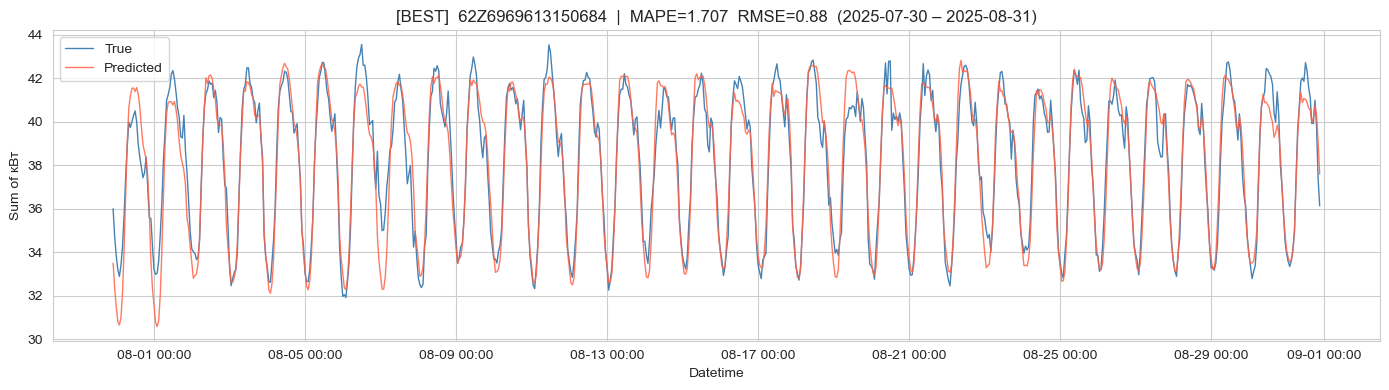

Worst station (SMAPE): 62Z0101426517156


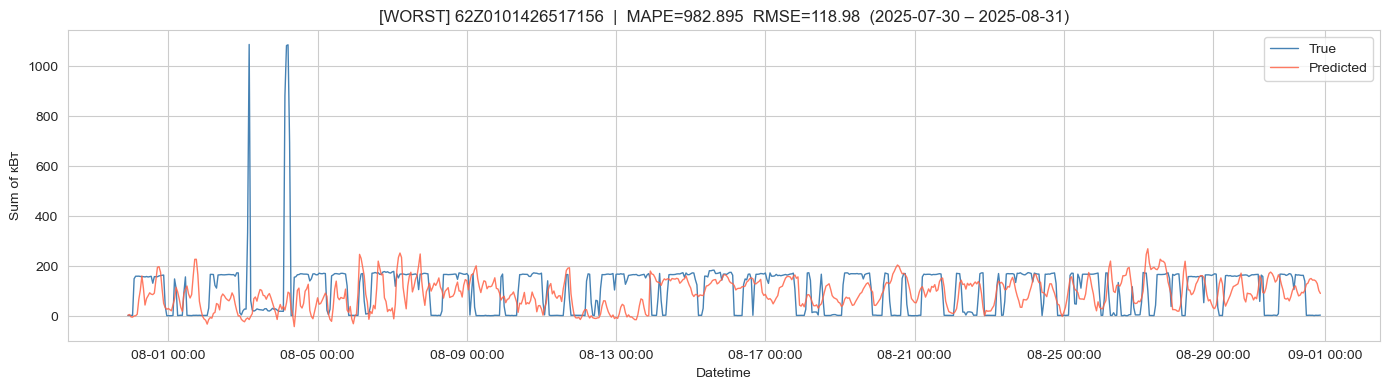

In [75]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates


def plot_forecast(eval_df, eic_code, start_dt=None, end_dt=None, title_prefix=""):
    df = eval_df.merge(
        all_data[[GROUP_COL, "time_idx", "datetime"]],
        on=[GROUP_COL, "time_idx"], how="inner",
    )
    df = df[df[GROUP_COL] == eic_code].sort_values("datetime")
    if df.empty:
        raise ValueError(f"No data for EIC code: {eic_code!r}")
    if start_dt is not None:
        df = df[df["datetime"] >= pd.Timestamp(start_dt)]
    if end_dt is not None:
        df = df[df["datetime"] <= pd.Timestamp(end_dt)]
    if df.empty:
        raise ValueError("No data in the specified datetime range.")

    fig, ax = plt.subplots(figsize=(14, 4))
    ax.plot(df["datetime"], df[Y_COL],  label="True",      linewidth=1, color="steelblue")
    ax.plot(df["datetime"], df["pred"], label="Predicted", linewidth=1, color="tomato", alpha=0.85)
    ax.set_title(
        f"{title_prefix}{eic_code}  |  "
        f"MAPE={mape(df[Y_COL], df['pred']):.3f}  "
        f"RMSE={rmse(df[Y_COL], df['pred']):.2f}  "
        f"({df['datetime'].min().date()} \u2013 {df['datetime'].max().date()})"
    )
    ax.set_xlabel("Datetime")
    ax.set_ylabel(Y_COL)
    ax.legend()
    ax.xaxis.set_major_locator(mdates.AutoDateLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%m-%d %H:%M"))
    fig.autofmt_xdate(rotation=0, ha="center")
    plt.tight_layout()
    plt.show()


# ── Auto-plot best and worst test stations ────────────────────────────────────
best_station  = test_station_metrics.iloc[0][GROUP_COL]
worst_station = test_station_metrics.iloc[-1][GROUP_COL]

print(f"Best  station (SMAPE): {best_station}")
plot_forecast(test_eval, eic_code=best_station,  title_prefix="[BEST]  ")

print(f"Worst station (SMAPE): {worst_station}")
plot_forecast(test_eval, eic_code=worst_station, title_prefix="[WORST] ")

# ── Uncomment to plot a specific station ─────────────────────────────────────
# plot_forecast(val_eval,  eic_code="62Z9042463861989")
# plot_forecast(test_eval, eic_code="62Z2410378897684", start_dt="2025-08-25", end_dt="2025-08-26")

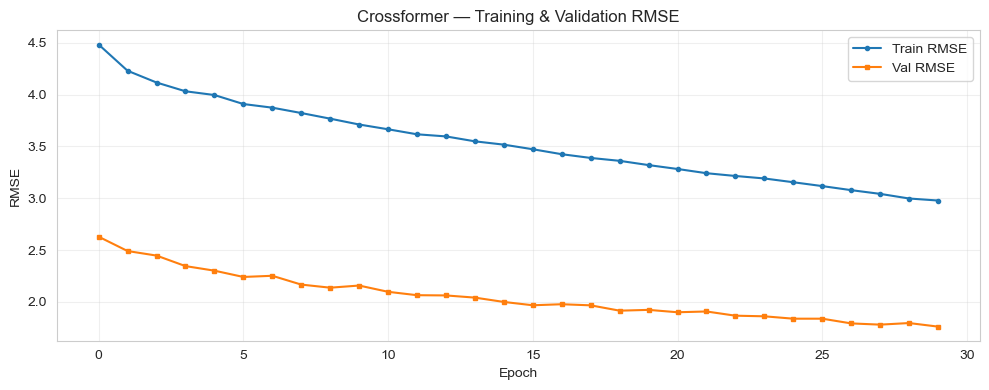

In [76]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(history["train_loss"], label="Train RMSE", marker="o", markersize=3)
ax.plot(history["val_loss"],   label="Val RMSE",   marker="s", markersize=3)
ax.set_xlabel("Epoch")
ax.set_ylabel("RMSE")
ax.set_title("Crossformer — Training & Validation RMSE")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()